In [1]:
import os
import pandas as pd
from ORBIT import ProjectManager, load_config
import csv
import matplotlib.pyplot as plt

# Separate Monopile and Turbine Install

In [2]:
#df would be the installation durations dataframe
def create_list_tuples_vessel_increases(df, max_percentage_raise, vessel_rate):
    tuple_list = list()
    baseline_dayrate = vessel_rate/ 24
    WTIV_time = df.loc[df['agent'] == "WTIV"] ['duration'].sum()
    port_time = df.loc[df['agent'] == "Port"] ['duration'].sum()
    baseline_port_fee = df.loc[df['agent'] == "Port"] ['day_rate'].iloc[0] / 24

    
    for i in range (0,max_percentage_raise+10, 10):
        increase = (1+i/100)
        install_cost = port_time * baseline_port_fee + WTIV_time * baseline_dayrate * increase
        tuple_list.append((i, install_cost))

    return tuple_list

def percentage_equalizer(df_1, df_2, vessel_rate):
    baseline_dayrate_1 = vessel_rate / 24
    WTIV_time_1 = df_1.loc[df_1['agent'] == "WTIV"] ['duration'].sum()
    port_time_1 = df_1.loc[df_1['agent'] == "Port"] ['duration'].sum()
    baseline_port_fee_1 = df_1.loc[df_1['agent'] == "Port"] ['day_rate'].iloc[0] / 24

    baseline_dayrate_2 = vessel_rate / 24
    WTIV_time_2 = df_2.loc[df_2['agent'] == "WTIV"] ['duration'].sum()
    port_time_2 = df_2.loc[df_2['agent'] == "Port"] ['duration'].sum()
    baseline_port_fee_2 = df_2.loc[df_2['agent'] == "Port"] ['day_rate'].iloc[0] / 24

    y = (baseline_port_fee_1 * port_time_1 - baseline_port_fee_2 * port_time_2) - baseline_dayrate_2 * WTIV_time_2 + baseline_dayrate_1 * WTIV_time_1
    x = 100 * y / (baseline_dayrate_2 * WTIV_time_2)
    return x


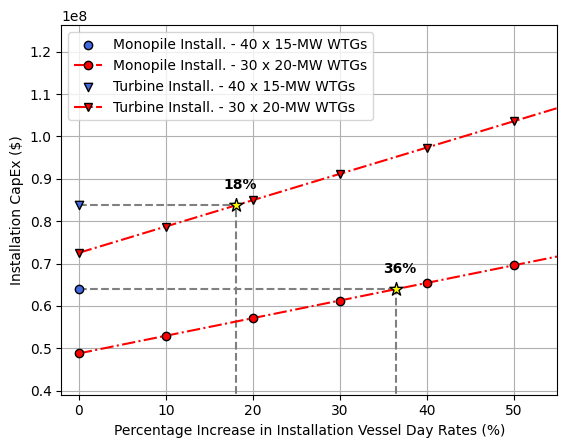

In [3]:
def plot_comparison(MW_15_list_monopile, MW_20_list_monopile, monopile_equalizer, MW_15_list_turbine, MW_20_list_turbine, turbine_equalizer, vessel_rate):

    x_val_15_mon = [x[0] for x in MW_15_list_monopile]
    y_val_15_mon = [x[1] for x in MW_15_list_monopile]

    x_val_20_mon = [x[0] for x in MW_20_list_monopile]
    y_val_20_mon = [x[1] for x in MW_20_list_monopile]

    x_val_15_tur = [x[0] for x in MW_15_list_turbine]
    y_val_15_tur = [x[1] for x in MW_15_list_turbine]

    x_val_20_tur = [x[0] for x in MW_20_list_turbine]
    y_val_20_tur = [x[1] for x in MW_20_list_turbine]
    
    plt.scatter(x_val_15_mon, y_val_15_mon, color = "royalblue", edgecolor = "black", marker = "o", zorder = 50)
    plt.plot(x_val_20_mon, y_val_20_mon, color = "red", marker = "o", zorder = 50, markeredgecolor = "black", linestyle = "-.")
    plt.scatter(x_val_15_tur, y_val_15_tur, color = "royalblue", edgecolor = "black", marker = "v", zorder = 50)
    plt.plot(x_val_20_tur, y_val_20_tur, color = "red", marker = "v", zorder = 50, markeredgecolor = "black", linestyle = "-.")
    
    plt.legend(["Monopile Install. - 40 x 15-MW WTGs", "Monopile Install. - 30 x 20-MW WTGs", "Turbine Install. - 40 x 15-MW WTGs", "Turbine Install. - 30 x 20-MW WTGs"], fontsize = 10, loc = "upper left")
    plt.plot([0, monopile_equalizer], [y_val_15_mon[0], y_val_15_mon[0]], "--", color = "grey")
    plt.plot([0, turbine_equalizer], [y_val_15_tur[0], y_val_15_tur[0]], "--", color = "grey")
    plt.plot([monopile_equalizer, monopile_equalizer], [0, y_val_15_mon[0]], "--", color = "grey")
    plt.plot([turbine_equalizer, turbine_equalizer], [0, y_val_15_tur[0]], "--", color = "grey")
    plt.scatter(monopile_equalizer, y_val_15_mon[0], color = "yellow", linewidth=1, marker = "*", edgecolor = "black", s = 100, zorder = 100)
    plt.scatter(turbine_equalizer, y_val_15_tur[0], color = "yellow", linewidth=1, marker = "*", edgecolor = "black", s = 100, zorder = 100)
    plt.text(monopile_equalizer - 1.5, y_val_15_mon[0]*1.06, str(int(monopile_equalizer+0.5))+"%", fontweight='bold')
    plt.text(turbine_equalizer - 1.5, y_val_15_tur[0]*1.045, str(int(turbine_equalizer+0.5))+"%", fontweight='bold')
    plt.xlim((-2, 55))
    plt.ylim((min(y_val_20_mon[0], y_val_20_mon[0])*0.8, max(y_val_20_tur[-1], y_val_20_tur[-1])*1.15))
    plt.ylabel('Installation CapEx ($)')
    plt.xlabel('Percentage Increase in Installation Vessel Day Rates (%)')
    plt.grid()
    plt.savefig("plots/vessel_" + str(vessel_rate/1000) + "k.svg")
    plt.show()

vessel_rate = 500000

df_15_mon = pd.read_csv("data/monopile_output_15_MW.csv")
df_20_mon = pd.read_csv("data/monopile_output_20_MW.csv")
MW_15_list_mon = create_list_tuples_vessel_increases(df_15_mon, 0, vessel_rate)
MW_20_list_mon = create_list_tuples_vessel_increases(df_20_mon, 60, vessel_rate)

df_15_tur = pd.read_csv("data/turbine_output_15_MW.csv")
df_20_tur = pd.read_csv("data/turbine_output_20_MW.csv")
MW_15_list_tur = create_list_tuples_vessel_increases(df_15_tur, 0, vessel_rate)
MW_20_list_tur  = create_list_tuples_vessel_increases(df_20_tur, 60, vessel_rate)


equalizer_mon = percentage_equalizer(df_15_mon, df_20_mon, vessel_rate)
equalizer_tur = percentage_equalizer(df_15_tur, df_20_tur, vessel_rate)


plot_comparison(MW_15_list_mon, MW_20_list_mon, equalizer_mon, MW_15_list_tur, MW_20_list_tur, equalizer_tur, vessel_rate)

# Merge Monopile and Turbine Install.

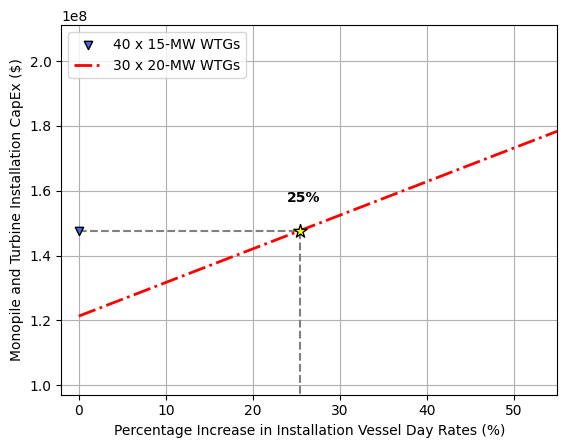

In [4]:
def plot_comparison_merged(MW_15_list, MW_20_list, equalizer, vessel_rate):

    x_val_15 = [x[0] for x in MW_15_list]
    y_val_15 = [x[1] for x in MW_15_list]

    x_val_20 = [x[0] for x in MW_20_list]
    y_val_20 = [x[1] for x in MW_20_list]

    
    plt.scatter(x_val_15, y_val_15, color = "royalblue", edgecolor = "black", marker = "v", zorder = 50)
    plt.plot(x_val_20, y_val_20, color = "red", linestyle = "-.", marker = None, zorder = 50, linewidth=2)
   
    
    plt.legend(["40 x 15-MW WTGs", "30 x 20-MW WTGs"], fontsize = 10, loc = "upper left")
    plt.plot([0, equalizer], [y_val_15[0], y_val_15[0]], "--", color = "grey")
    
    plt.plot([equalizer, equalizer], [0, y_val_15[0]], "--", color = "grey")
    
    plt.scatter(equalizer, y_val_15[0], color = "yellow", linewidth=1, marker = "*", edgecolor = "black", s = 100, zorder = 100)
    
    plt.text(equalizer - 1.5, y_val_15[0]*1.06, str(int(equalizer+0.5))+"%", fontweight='bold')
    
    plt.xlim((-2, 55))
    plt.ylim((min(y_val_20[0], y_val_20[0])*0.8, max(y_val_20[-1], y_val_20[-1])*1.15))
    plt.ylabel('Monopile and Turbine Installation CapEx ($)')
    plt.xlabel('Percentage Increase in Installation Vessel Day Rates (%)')
    #plt.title('Fixed-bottom')
    plt.grid()
    plt.savefig("plots/merged_vessels_" + str(vessel_rate/1000) + "k.svg") 
    plt.show()
    
vessel_rate = 500000
df_15_mon = pd.read_csv("data/monopile_output_15_MW.csv")
df_20_mon = pd.read_csv("data/monopile_output_20_MW.csv")
df_15_tur = pd.read_csv("data/turbine_output_15_MW.csv")
df_20_tur = pd.read_csv("data/turbine_output_20_MW.csv")

df_15 = pd.concat([df_15_mon, df_15_tur], axis=0)
df_20 = pd.concat([df_20_mon, df_20_tur], axis=0)

MW_15_list = create_list_tuples_vessel_increases(df_15, 0, vessel_rate)
MW_20_list = create_list_tuples_vessel_increases(df_20, 60, vessel_rate)

equalizer = percentage_equalizer(df_15, df_20, vessel_rate)
#print(equalizer)

plot_comparison_merged(MW_15_list, MW_20_list, equalizer, vessel_rate)

# Loop changing dayrates

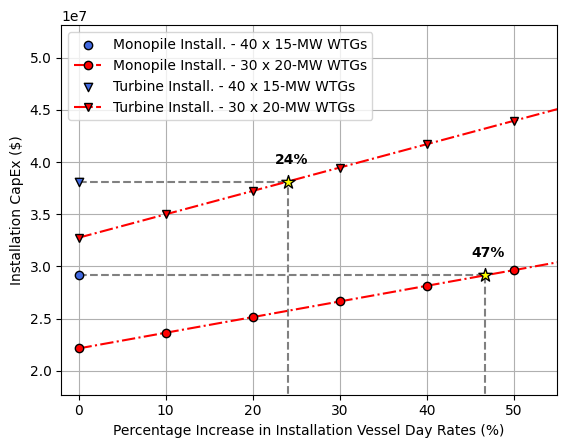

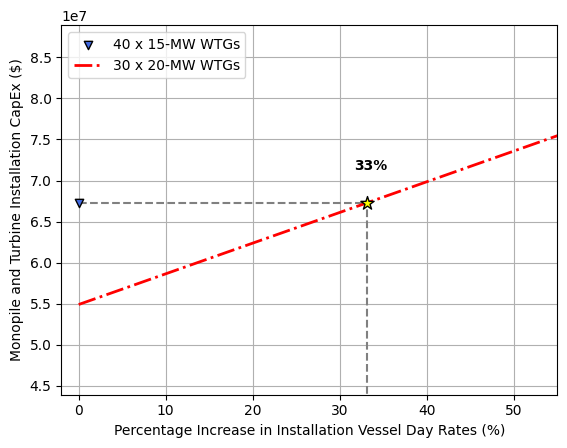

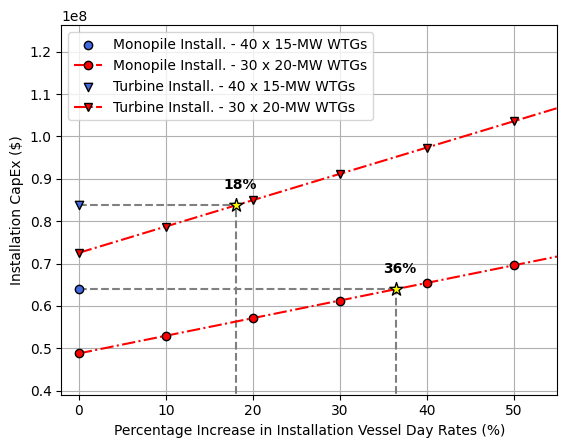

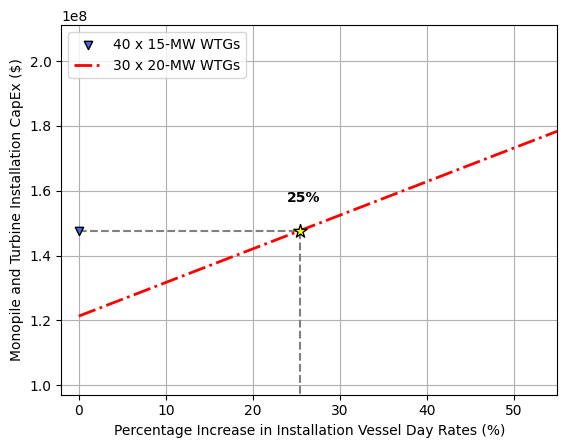

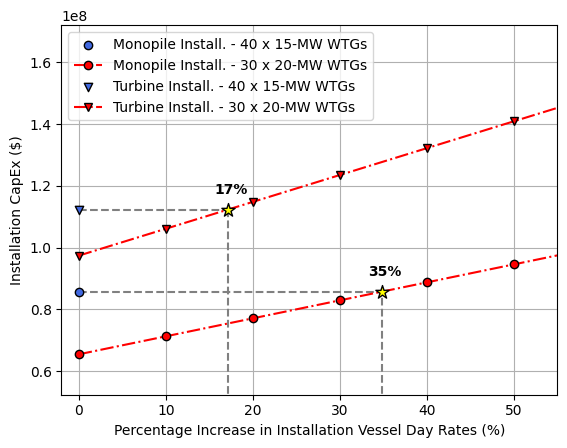

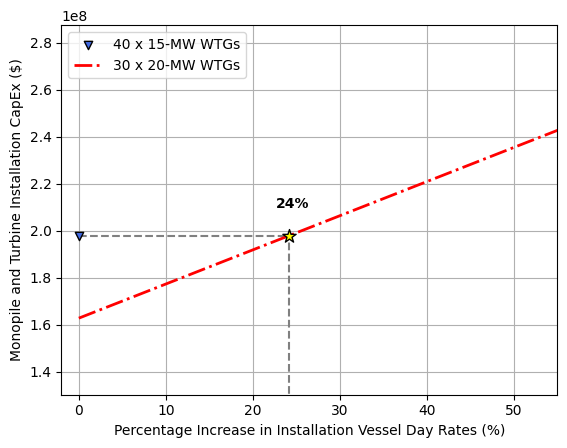

In [5]:
vessel_rates = [180000, 500000, 700000]
df_15_mon = pd.read_csv("data/monopile_output_15_MW.csv")
df_20_mon = pd.read_csv("data/monopile_output_20_MW.csv")
df_15_tur = pd.read_csv("data/turbine_output_15_MW.csv")
df_20_tur = pd.read_csv("data/turbine_output_20_MW.csv")
df_15 = pd.concat([df_15_mon, df_15_tur], axis=0)
df_20 = pd.concat([df_20_mon, df_20_tur], axis=0)
for i in vessel_rates:
    
    MW_15_list_mon = create_list_tuples_vessel_increases(df_15_mon, 0, i)
    MW_20_list_mon = create_list_tuples_vessel_increases(df_20_mon, 60, i)


    MW_15_list_tur = create_list_tuples_vessel_increases(df_15_tur, 0, i)
    MW_20_list_tur  = create_list_tuples_vessel_increases(df_20_tur, 60, i)

    MW_15_list = create_list_tuples_vessel_increases(df_15, 0, i)
    MW_20_list = create_list_tuples_vessel_increases(df_20, 60, i)


    equalizer_mon = percentage_equalizer(df_15_mon, df_20_mon, i)
    equalizer_tur = percentage_equalizer(df_15_tur, df_20_tur, i)
    equalizer = percentage_equalizer(df_15, df_20, i)

    plot_comparison(MW_15_list_mon, MW_20_list_mon, equalizer_mon, MW_15_list_tur, MW_20_list_tur, equalizer_tur, i)
    plot_comparison_merged(MW_15_list, MW_20_list, equalizer, i)
    